In [8]:
import numpy as np
import matplotlib.pyplot as plt


from thermosim.utils.io import load_irb_txt

In [9]:
from pathlib import Path

folder = Path("../data/Thermografiemessungen/Lochplatten - transiente Abkühlung/ThSi_Messung2_Lochplatte_klein")
csv_files = sorted(folder.glob("*.csv"))
print(f"Found {len(csv_files)} files")

frames = []
for f in csv_files:
    arr, settings, params = load_irb_txt(str(f))
    frames.append({"arr": arr, "settings": settings, "params": params})

print("Data shape per frame:", frames[0]["arr"].shape)
print("Settings:", frames[0]["settings"])
print("Params:", frames[0]["params"])

Found 9 files
Data shape per frame: (333, 507)
Settings: {'Version': 3, 'ImageWidth': 507, 'ImageHeight': 333, 'ShotRange': [21.6, 53.6], 'CalibRange': [-40.15, 119.85], 'TempUnit': '°C', 'StartPos': [42, 90], 'EndPos': [548, 422]}
Params: {'Filename': 'Laminiertisch gross_0002.irb', 'FrameIndex': 2, 'RecDate': '04.12.2025', 'RecTime': '14:41:36', 'ms': 30018.75}


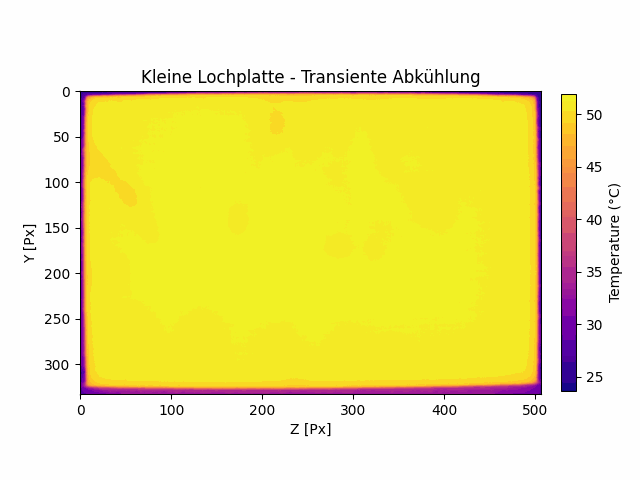

In [10]:
import matplotlib.animation as animation
from IPython.display import Image as IPyImage

all_arrs = [f["arr"] for f in frames]
vmin = min(a.min() for a in all_arrs)
vmax = max(a.max() for a in all_arrs)

fig, ax = plt.subplots()
im = ax.imshow(all_arrs[0], cmap="plasma", vmin=vmin, vmax=vmax)
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04, label="Temperature (°C)")
ax.set_title("Kleine Lochplatte - Transiente Abkühlung")
ax.set_xlabel("Z [Px]")
ax.set_ylabel("Y [Px]")

def update(i):
    im.set_data(all_arrs[i])
    return (im,)

ani = animation.FuncAnimation(fig, update, frames=len(all_arrs), interval=300, blit=True)
ani.save("../results/cooling.gif", writer="pillow", dpi=100)
plt.close()

IPyImage("../results/cooling.gif")

In [11]:
import cv2
def undistort_image(img, K, dist, alpha=0.0):
    """
    alpha=0.0 -> crop to valid pixels (no black border)
    alpha=1.0 -> keep all pixels (more black border)
    """
    h, w = img.shape[:2]
    newK, roi = cv2.getOptimalNewCameraMatrix(K, dist, (w, h), alpha, (w, h))
    und = cv2.undistort(img, K, dist, None, newK)
    return und, newK, roi

## Load the Calibration File

### Camera Calibration Parameters

**Camera matrix K** (intrinsics) maps 3D scene points to 2D pixel coordinates:

$$K = \begin{bmatrix} f_x & 0 & c_x \\ 0 & f_y & c_y \\ 0 & 0 & 1 \end{bmatrix}$$

| Symbol | Value | Meaning |
|--------|-------|---------|
| $f_x$ | 1185.8 px | Focal length in x (horizontal pixels per unit depth) |
| $f_y$ | 1845.5 px | Focal length in y — higher than $f_x$ indicates non-square pixels (IR sensor) |
| $c_x$ | 219.4 px | Principal point x — optical axis offset from image left |
| $c_y$ | 202.4 px | Principal point y — optical axis offset from image top |

**Distortion coefficients** `dist = [k1, k2, p1, p2, k3]` model lens aberrations:

| Symbol | Value | Type | Effect |
|--------|-------|------|--------|
| $k_1$ | −0.4395 | Radial | Barrel/pincushion; negative = barrel distortion |
| $k_2$ | −8.252 | Radial | Higher-order radial; large magnitude typical for short focal lengths |
| $p_1$ | 0.0216 | Tangential | Lens tilt (vertical axis) |
| $p_2$ | 0.0162 | Tangential | Lens tilt (horizontal axis) |
| $k_3$ | 0.0 | Radial | Fixed to zero — unnecessary for most lenses |

**Undistortion** works in two steps:
1. `cv2.getOptimalNewCameraMatrix` computes a new K that maps undistorted pixels into the image area (`alpha=0.0` crops to only valid pixels, `alpha=1.0` keeps all pixels with black borders).
2. `cv2.undistort` applies the inverse distortion model — for each output pixel it traces back through the distortion polynomial to find the corresponding source pixel and interpolates.

In [ ]:
calib = np.load("../data/ir_calib_ref.npz")
K = calib["K"]
dist = calib["dist"].flatten()

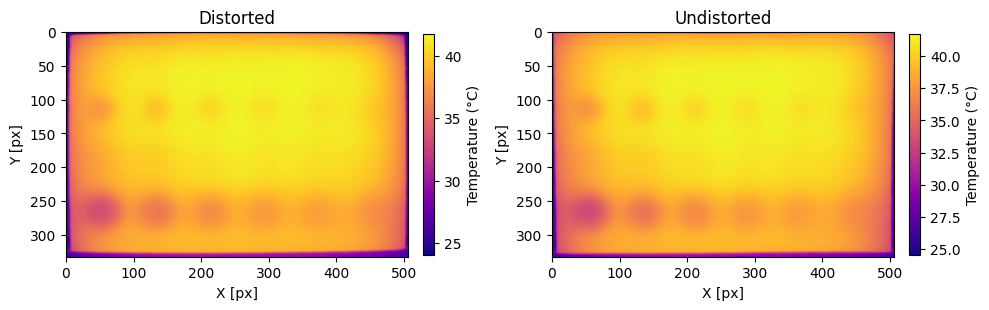

In [31]:
arr = frames[5]["arr"]
img_, _, _ = undistort_image(arr, K, dist)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, data, title in zip(axes, [arr, img_], ["Distorted", "Undistorted"]):
    im = ax.imshow(data, cmap="plasma")
    ax.set_title(title)
    ax.set_xlabel("X [px]")
    ax.set_ylabel("Y [px]")
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04, label="Temperature (°C)")

plt.tight_layout()
plt.show()

In [41]:
import meshio

# Working distance from camera to surface in mm.
# Derive from calibration: Z = square_size * f / corner_spacing_px
# Or measure directly. Adjust to your setup.
Z_mm = 600.0

fx = K[0, 0]
fy = K[1, 1]
dx_mm = Z_mm / fx   # mm per pixel in x
dy_mm = Z_mm / fy   # mm per pixel in y

und = img_.astype(np.float64)
H, W = und.shape

xs = np.arange(W, dtype=np.float64) * dx_mm
ys = np.arange(H, dtype=np.float64) * dy_mm
xv, yv = np.meshgrid(xs, ys)
points = np.column_stack([xv.ravel(), yv.ravel(), np.zeros(W * H)])

i, j = np.meshgrid(np.arange(W - 1), np.arange(H - 1))
i, j = i.ravel(), j.ravel()
idx = j * W + i
cells = np.column_stack([idx, idx + 1, idx + W + 1, idx + W])

mesh = meshio.Mesh(
    points=points,
    cells=[("quad", cells)],
    point_data={"temperature": und.ravel()},
    field_data={"dx_mm": np.array([dx_mm]), "dy_mm": np.array([dy_mm])},
)

out_path = "../results/undistorted_thermal.vtu"
meshio.write(out_path, mesh)
print(f"Saved {out_path}")
print(f"Spatial resolution: dx={dx_mm:.4f} mm/px, dy={dy_mm:.4f} mm/px")
print(f"Field of view: {W * dx_mm:.1f} x {H * dy_mm:.1f} mm  (at Z={Z_mm} mm)")

Saved ../results/undistorted_thermal.vtu
Spatial resolution: dx=0.5060 mm/px, dy=0.3251 mm/px
Field of view: 256.5 x 108.3 mm  (at Z=600.0 mm)
